# Member 3 — Classification Track, Part A (Adult / Census Income)

**Owner:** Vikranth  |  **Review 1 scope:** Classification Part A — Logistic Regression, KNN, Gaussian Naive Bayes,
Decision Tree, SVC.

- Dataset: UCI Adult (`data/raw/adult/adult_train.csv` + `adult_test.csv`, 48,842 rows, 14 features).
- Target: `income` (`<=50K` / `>50K`), binary classification.
- Pipeline: audit -> cleaning -> EDA -> outliers -> feature engineering -> encoding / stratified 80:20 split / scaling
  -> 5 models -> tuning -> evaluation (accuracy, precision, recall, weighted F1, ROC-AUC, confusion matrix) -> 5-fold CV.
- Reproducibility: `random_state=42` everywhere; every scaler/encoder is fitted on the training set only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='colorblind')
PALETTE = {'<=50K': '#0072B2', '>50K': '#D55E00'}   # colour-blind-safe pair used for the target everywhere

RESULTS_DIR = Path('../results/classification')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / name, dpi=150, bbox_inches='tight')

## 1. Load data and audit

UCI ships the Adult data as a fixed train/test pair (32,561 + 16,281 rows). The guidelines ask for one consistent,
**stratified 80:20** split, so the two files are pooled here and re-split later (section 6). The audit below reports
shape, dtypes, missing values (`?` is this dataset's missing marker), duplicates and the class distribution.

In [2]:
raw_train = pd.read_csv('../data/raw/adult/adult_train.csv')
raw_test = pd.read_csv('../data/raw/adult/adult_test.csv')
df = pd.concat([raw_train, raw_test], ignore_index=True)

print('train file:', raw_train.shape, '| test file:', raw_test.shape, '| pooled:', df.shape)
print('duplicate rows:', df.duplicated().sum())
print('\nlabel values before cleaning:', sorted(df['income'].unique()))

audit = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(),
    "'?' count": (df == '?').sum(),
    'NaN count': df.isna().sum(),
})
display(audit)
display(df.head())

train file: (32561, 15) | test file: (16281, 15) | pooled: (48842, 15)
duplicate rows: 52

label values before cleaning: ['<=50K', '>50K']


,dtype,n_unique,'?' count,NaN count
age,int64,74,0,0
workclass,object,9,2799,0
fnlwgt,int64,28523,0,0
education,object,16,0,0
education-num,int64,16,0,0
marital-status,object,7,0,0
occupation,object,15,2809,0
relationship,object,6,0,0
race,object,5,0,0
sex,object,2,0,0


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 2. Cleaning

Strategy and justification:
- **`?` -> missing -> drop the row.** Only `workclass`, `occupation` and `native-country` contain `?`, and they are
  categorical, so a median/mean is meaningless and a "?" category would be noise. About 7% of rows are affected, so
  dropping loses little and avoids inventing values.
- **Whitespace and label normalisation.** Text columns are stripped and a trailing `.` on the label
  (`>50K.` in the original test file) is removed so both classes have exactly two spellings.
- **Duplicates removed** (identical rows carry no extra information and can leak between train and test).

In [3]:
df = df.replace('?', np.nan)

for col in df.select_dtypes(exclude='number').columns:
    df[col] = df[col].str.strip()
df['income'] = df['income'].str.rstrip('.')

n0 = len(df)
df = df.dropna().reset_index(drop=True)
n1 = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n2 = len(df)

print(f'rows: {n0} -> {n1} after dropping missing ({n0 - n1} removed) -> {n2} after dropping duplicates ({n1 - n2} removed)')
print('label values after cleaning:', sorted(df['income'].unique()))
print('remaining NaN:', int(df.isna().sum().sum()))

rows: 48842 -> 45222 after dropping missing (3620 removed) -> 45175 after dropping duplicates (47 removed)
label values after cleaning: ['<=50K', '>50K']
remaining NaN: 0


## 3. Exploratory data analysis

Every plot below has a title, labelled axes and a legend where the target is colour-coded; each is followed by a
written observation. Orange = `>50K`, blue = `<=50K` (colour-blind-safe).

### 3.1 Target distribution

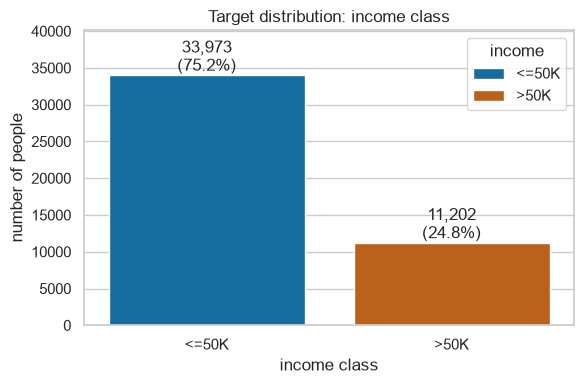

In [4]:
counts = df['income'].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='income', hue='income', order=['<=50K', '>50K'], palette=PALETTE, legend=True, ax=ax)
for i, label in enumerate(['<=50K', '>50K']):
    ax.text(i, counts[label], f'{counts[label]:,}\n({counts[label] / len(df):.1%})', ha='center', va='bottom')
ax.set_title('Target distribution: income class')
ax.set_xlabel('income class')
ax.set_ylabel('number of people')
ax.set_ylim(0, counts.max() * 1.18)
save_fig('eda_target_distribution.png')
plt.show()

**Observation.** The classes are imbalanced: about 75% earn `<=50K` and 25% earn `>50K`. A model that always predicts
`<=50K` would already score ~75% accuracy, so accuracy alone is misleading; weighted/macro F1, balanced accuracy,
recall and ROC-AUC are reported too and `class_weight='balanced'` is used where a model supports it.

### 3.2 Distribution of every numeric feature

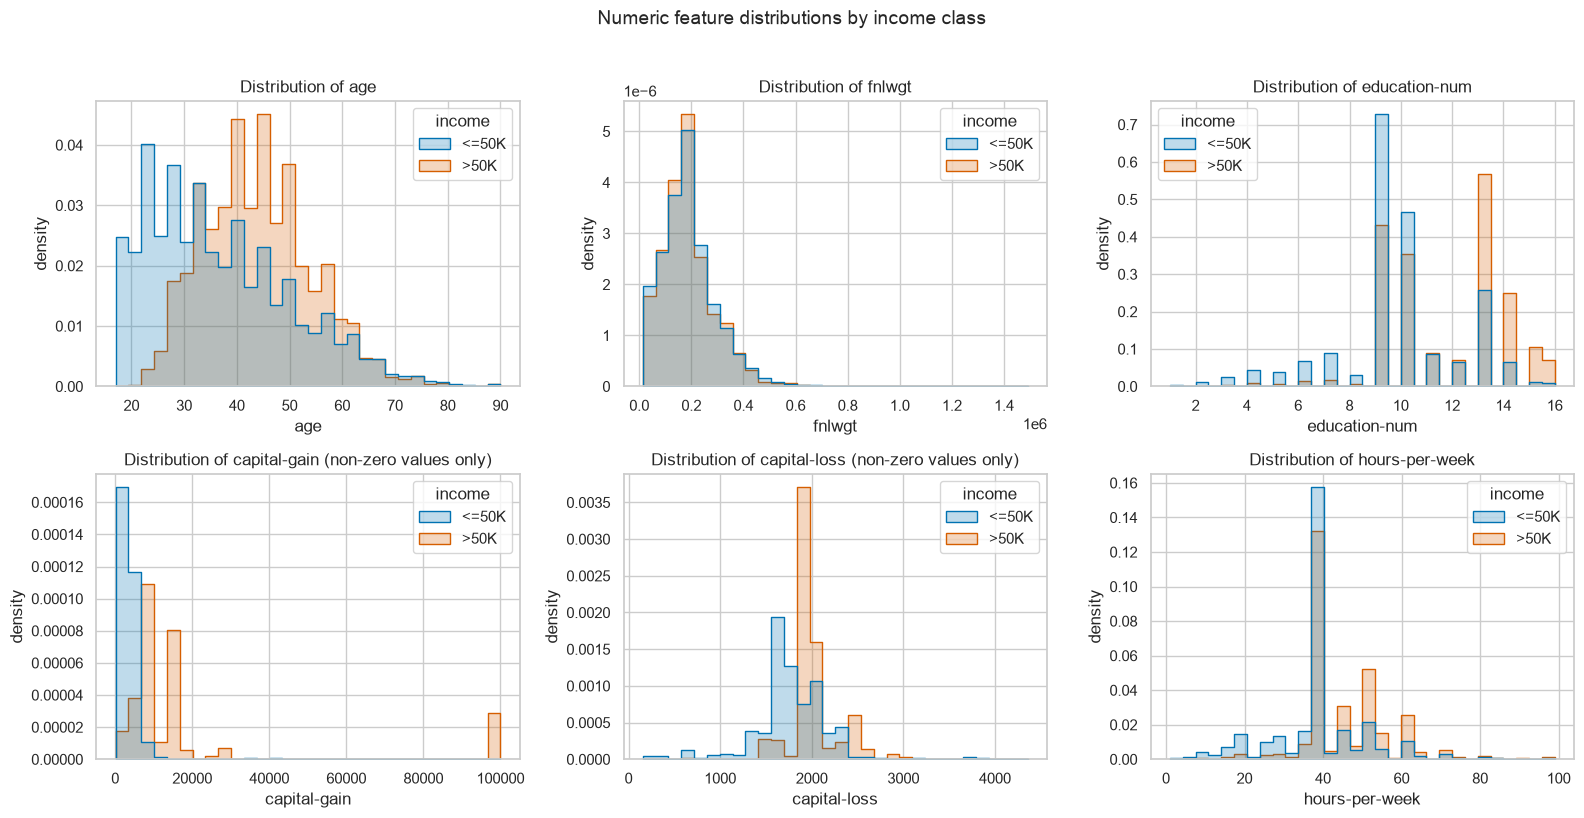

share of people with capital-gain > 0: 0.084
share of people with capital-loss > 0: 0.047
skewness: {'age': 0.53, 'fnlwgt': 1.45, 'education-num': -0.31, 'capital-gain': 11.78, 'capital-loss': 4.51, 'hours-per-week': 0.34}


In [5]:
num_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), num_features):
    data = df[df[col] > 0] if col in ('capital-gain', 'capital-loss') else df
    sns.histplot(data=data, x=col, hue='income', bins=30, stat='density', common_norm=False,
                 element='step', palette=PALETTE, ax=ax)
    suffix = ' (non-zero values only)' if col in ('capital-gain', 'capital-loss') else ''
    ax.set_title(f'Distribution of {col}{suffix}')
    ax.set_xlabel(col)
    ax.set_ylabel('density')
fig.suptitle('Numeric feature distributions by income class', y=1.02, fontsize=14)
save_fig('eda_numeric_distributions.png')
plt.show()

print('share of people with capital-gain > 0:', round((df['capital-gain'] > 0).mean(), 3))
print('share of people with capital-loss > 0:', round((df['capital-loss'] > 0).mean(), 3))
print('skewness:', df[num_features].skew().round(2).to_dict())

**Observation.**
- `capital-gain` and `capital-loss` are zero for ~92% and ~95% of people and extremely right-skewed
  (skewness ~11.8 and ~4.5). `capital-gain` is also top-coded at 99,999 (229 people), which is a censoring value, not a real amount.
- `age` is right-skewed around 37; `hours-per-week` has a sharp spike at 40 (the standard work week); `education-num` is discrete.
- `fnlwgt` (census sampling weight) looks the same for both classes, so it carries no information about a person's income.

### 3.3 Distribution of every categorical feature

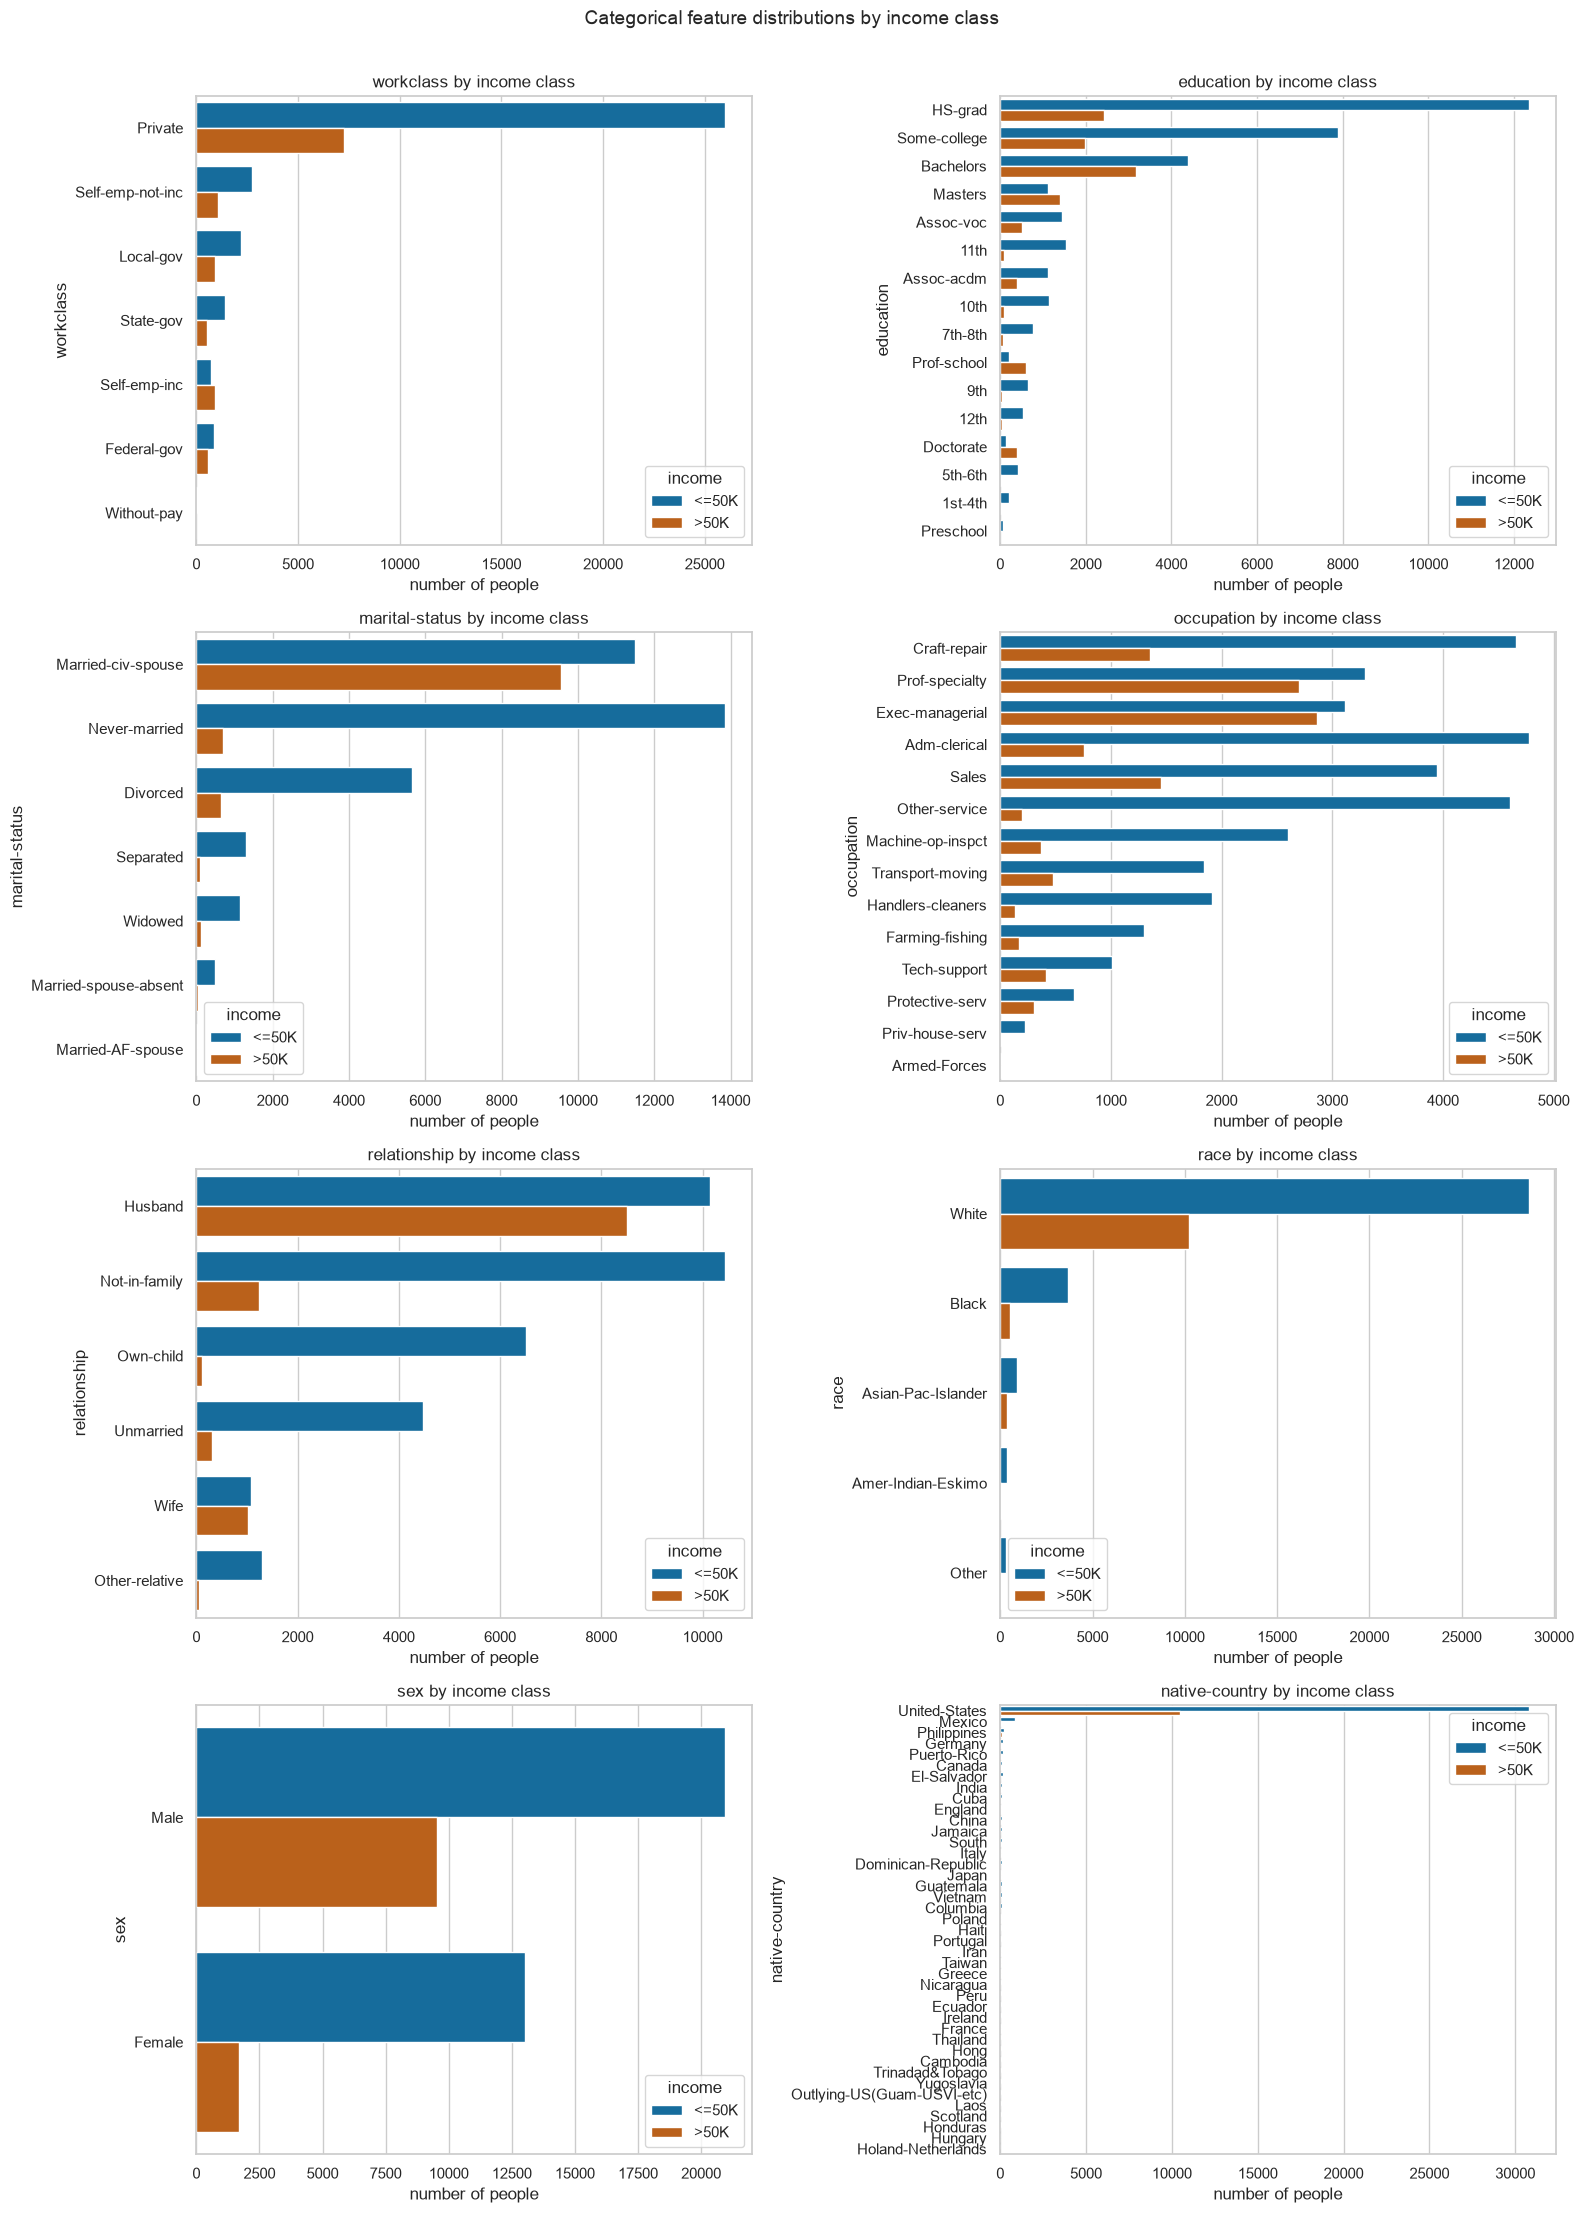

share earning >50K by sex: {'Female': 0.114, 'Male': 0.313}
share earning >50K, married-civ-spouse vs divorced: 0.454 vs 0.104
share earning >50K, education-num >= 13 vs < 13: 0.488 vs 0.167
share of people from United-States: 0.913


In [6]:
cat_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
for ax, col in zip(axes.ravel(), cat_features):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue='income', order=order, palette=PALETTE, ax=ax)
    ax.set_title(f'{col} by income class')
    ax.set_xlabel('number of people')
    ax.set_ylabel(col)
fig.suptitle('Categorical feature distributions by income class', y=1.005, fontsize=14)
save_fig('eda_categorical_distributions.png')
plt.show()

y_bin = (df['income'] == '>50K')
print('share earning >50K by sex:', y_bin.groupby(df['sex']).mean().round(3).to_dict())
print('share earning >50K, married-civ-spouse vs divorced:',
      round(y_bin[df['marital-status'] == 'Married-civ-spouse'].mean(), 3), 'vs',
      round(y_bin[df['marital-status'] == 'Divorced'].mean(), 3))
print('share earning >50K, education-num >= 13 vs < 13:',
      round(y_bin[df['education-num'] >= 13].mean(), 3), 'vs', round(y_bin[df['education-num'] < 13].mean(), 3))
print('share of people from United-States:', round((df['native-country'] == 'United-States').mean(), 3))

**Observation.**
- Marital status is the strongest categorical signal: 45% of married-civ-spouse people earn `>50K` versus 10% of divorced people.
- Education matters: 49% of people with a bachelor's degree or higher (`education-num >= 13`) earn `>50K` versus 17% of the rest.
- Men earn `>50K` about 2.7x as often as women (31% vs 11%) in this 1994 census sample.
- `native-country` is dominated by one value (91% United-States) and `race` is also highly concentrated, so those columns add little beyond noise; `education` duplicates `education-num`.

### 3.4 Correlation heatmap

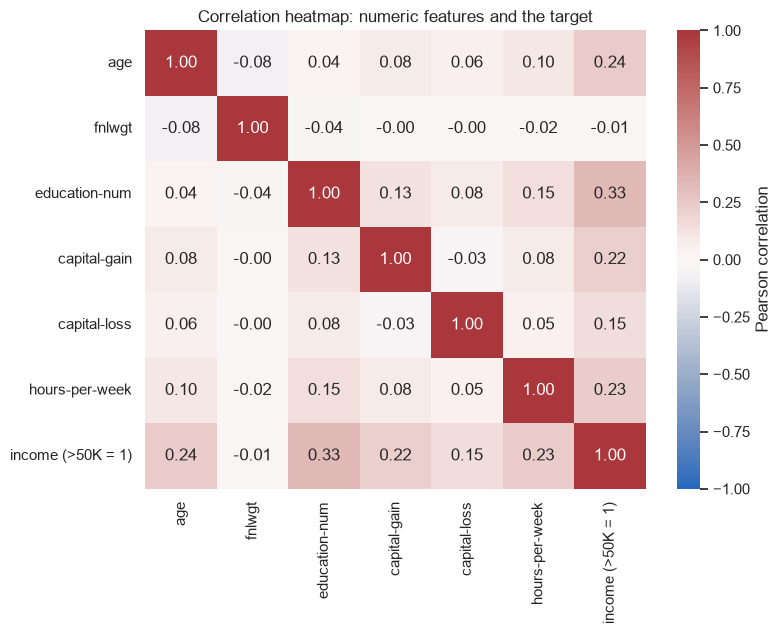

In [7]:
corr_frame = df[num_features].copy()
corr_frame['income (>50K = 1)'] = y_bin.astype(int)
plt.figure(figsize=(8, 6.5))
sns.heatmap(corr_frame.corr(), annot=True, fmt='.2f', cmap='vlag', center=0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation heatmap: numeric features and the target')
save_fig('eda_correlation_heatmap.png')
plt.show()

**Observation.** Correlations with the target are moderate at best: `education-num` (0.33), `age` (0.24), `hours-per-week` (0.23),
`capital-gain` (0.22) and `capital-loss` (0.15). `fnlwgt` is essentially zero (-0.01), confirming it should be dropped. No pair of
numeric predictors is strongly collinear, so there is no need to drop any numeric column for multicollinearity.

### 3.5 Feature vs target relationships (scatter plots)

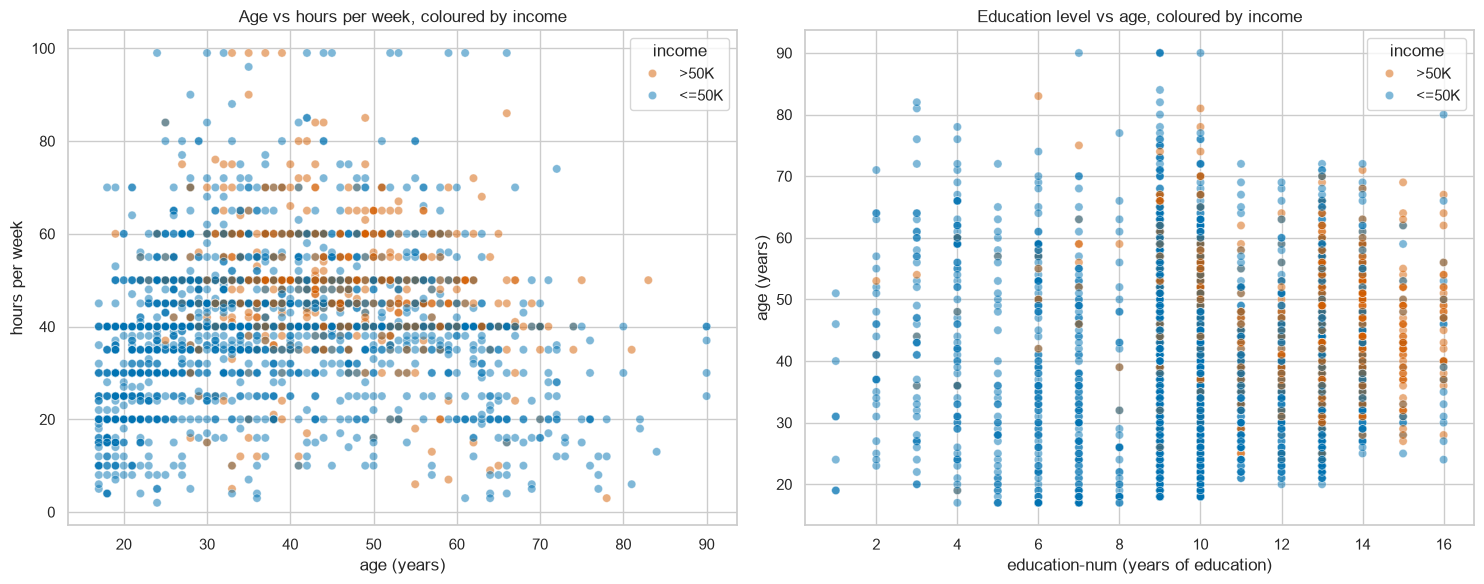

mean age by income: {'<=50K': 36.8, '>50K': 44.0}
mean hours-per-week by income: {'<=50K': 39.4, '>50K': 45.7}


In [8]:
sample = df.sample(4000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=sample, x='age', y='hours-per-week', hue='income', palette=PALETTE, alpha=0.5, ax=axes[0])
axes[0].set_title('Age vs hours per week, coloured by income')
axes[0].set_xlabel('age (years)')
axes[0].set_ylabel('hours per week')

sns.scatterplot(data=sample, x='education-num', y='age', hue='income', palette=PALETTE, alpha=0.5, ax=axes[1])
axes[1].set_title('Education level vs age, coloured by income')
axes[1].set_xlabel('education-num (years of education)')
axes[1].set_ylabel('age (years)')

save_fig('eda_scatter_plots.png')
plt.show()

print('mean age by income:', df.groupby('income')['age'].mean().round(1).to_dict())
print('mean hours-per-week by income:', df.groupby('income')['hours-per-week'].mean().round(1).to_dict())

**Observation** (random sample of 4,000 people). `>50K` earners sit at higher ages and longer working hours: mean age 44.0 vs 36.8 and mean
hours 45.7 vs 39.4. Almost no one under ~25 earns `>50K`, and among people with 13+ years of education the orange points dominate the
middle-aged band, so `age`, `hours-per-week` and `education-num` all help separate the classes, but no single feature separates them cleanly.

## 4. Outlier check and treatment

Outliers are counted with the IQR rule (values outside Q1 - 1.5 IQR ... Q3 + 1.5 IQR). The rule is only a screening
tool here, and the treatment depends on *why* the values are extreme:

| Feature | Finding | Treatment |
|---|---|---|
| `capital-gain`, `capital-loss` | zero for >90% of people, extreme skew, `capital-gain` top-coded at 99,999 | **`log1p` transform** compresses the long tail without deleting the rare, informative rows |
| `age`, `hours-per-week` | flagged values are real (ages up to 90, 1-99 h/week) | **kept** - they are valid observations, not errors |
| `education-num` | discrete 1-16 scale | kept |
| `fnlwgt` | census sampling weight, unrelated to income (r = -0.01) | **dropped** (section 6) |

`log1p` is applied row by row (no statistic is learned from the data), so it cannot leak information from the test set.

In [9]:
outlier_cols = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'fnlwgt']
rows = []
for col in outlier_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum())
    rows.append({'feature': col, 'outliers (IQR rule)': n_out, '% of rows': round(100 * n_out / len(df), 2),
                 'skewness': round(df[col].skew(), 2)})
outlier_table = pd.DataFrame(rows).set_index('feature')
display(outlier_table)

,outliers (IQR rule),% of rows,skewness
feature,,,
age,268,0.59,0.53
education-num,290,0.64,-0.31
capital-gain,3790,8.39,11.78
capital-loss,2140,4.74,4.51
hours-per-week,11889,26.32,0.34
fnlwgt,1332,2.95,1.45


In [10]:
df_model = df.copy()
skew_before = df_model[['capital-gain', 'capital-loss']].skew()

df_model['capital-gain'] = np.log1p(df_model['capital-gain'])
df_model['capital-loss'] = np.log1p(df_model['capital-loss'])

print('skewness before log1p:', skew_before.round(2).to_dict())
print('skewness after  log1p:', df_model[['capital-gain', 'capital-loss']].skew().round(2).to_dict())

skewness before log1p: {'capital-gain': 11.78, 'capital-loss': 4.51}
skewness after  log1p: {'capital-gain': 3.08, 'capital-loss': 4.27}


**Result.** `log1p` cuts the skewness of `capital-gain` from 11.8 to 3.1. `capital-loss` barely changes (4.5 to 4.3) because ~95% of its values are zero, so
the remaining skew comes from that spike at zero rather than from extreme values; the rare non-zero rows are kept because they are informative. Age and hours are left as they are.

## 5. Feature engineering

Two new features were created, each with a reason to help the models:

1. **`net_capital`** = signed `log1p` of (`capital-gain` - `capital-loss`). A person has either a gain or a loss, so the two
   columns describe one thing - net investment income. A single signed value lets a linear model (Logistic Regression)
   and distance-based models (KNN, SVC) use it directly. Investment income is a strong wealth signal: 63% of people with a
   capital gain earn `>50K` versus 24.8% overall.
2. **`overtime`** = 1 if `hours-per-week` > 40. The EDA showed a spike at 40 hours and that `>50K` earners work more
   (mean 45.7 vs 39.4 h). A binary flag captures the "beyond a full-time week" effect that a linear model cannot get from the raw
   hour count, whose relationship with income is not a straight line.

In [11]:
net_capital = df['capital-gain'] - df['capital-loss']          # from the raw (untransformed) values
df_model['net_capital'] = np.sign(net_capital) * np.log1p(net_capital.abs())
df_model['overtime'] = (df['hours-per-week'] > 40).astype(int)

y_bin = df['income'] == '>50K'
print('share earning >50K with capital-gain > 0:', round(y_bin[df['capital-gain'] > 0].mean(), 3), '| overall:', round(y_bin.mean(), 3))
print('share earning >50K, overtime vs not:',
      round(y_bin[df_model['overtime'] == 1].mean(), 3), 'vs', round(y_bin[df_model['overtime'] == 0].mean(), 3))
display(df_model[['capital-gain', 'capital-loss', 'net_capital', 'hours-per-week', 'overtime']].head())

share earning >50K with capital-gain > 0: 0.627 | overall: 0.248
share earning >50K, overtime vs not: 0.404 vs 0.179


,capital-gain,capital-loss,net_capital,hours-per-week,overtime
0,7.684784,0.0,7.684784,40,0
1,0.000000,0.0,0.000000,13,0
2,0.000000,0.0,0.000000,40,0
3,0.000000,0.0,0.000000,40,0
4,0.000000,0.0,0.000000,40,0
